In [1]:
%load_ext autoreload
%autoreload 2
from reward_relative.path_dict_seahorse import path_dictionary as path_dict
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import placeCellPlot
from reward_relative import dayData as dd
from reward_relative import behavior
import pickle
import dill
import numpy as np
import os 
import matplotlib.pyplot as plt
import TwoPUtils
import protter_functions as pf
from scipy.signal import medfilt
from matplotlib.lines import Line2D

In [2]:


experiment = 'MetaLearn'
year = 'combined'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment, exp_days, year=year)

## These parameters were used for computing the saved multiDayData
# bin_size = 10  # for quantifying distribution of place field peak locations
# sigma = 1  # for smoothing
# smooth = False  # whether to smooth for finding place cell peaks
# exclude_int = True  # exclude putative interneurons
# int_thresh = 0.5

## Place cell logical definitions:
## 'and' = must have significant spatial information
## in trial set 0 AND trial set 1 (i.e. before and after the reward switch)
## 'or' = must have signitive spatial information in trial set 0 OR trial set 1

# place_cell_logical = 'or'
ts_key = 'dff'  # which timeseries to use for finding peaks
# use_speed_thr = True  # use a speed threshold to calculate new trial matrices
# # speed threshold in cm/s (excludes data at speed less than this)
# speed_thr = 2

reward_dist_inclusive = 50  # in cm

# datetime of saved file
dt = "202504"

pkl_name = "%s_expdays%s_multiDayData_%s_%s.pickle" % (
    # ut.make_anim_tag(max_anim_list),
    f'm{ut.get_mouse_number(max_anim_list[0])}-{ut.get_mouse_number(max_anim_list[-1])}',
    ut.make_day_tag(
        exp_days),
    ts_key,
    dt)
pkl_path = os.path.join(
    path_dict['preprocessed_root'], 'multi_anim_sess', pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path, "rb"), ignore=True)

include_ans = multiDayData[exp_days[-1]
                           ].circ_rel_stats_across_an['include_ans']
max_anim_list = sorted(np.unique(np.concatenate([multiDayData[day].anim_list
                                                 for day in exp_days])),
                       key=len)
include_ans


/data/2p_data/multi_anim_sess/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


array(['GCAMP3', 'GCAMP4', 'GCAMP7', 'GCAMP11', 'GCAMP12', 'GCAMP13',
       'GCAMP14', 'GCAMP15', 'GCAMP17', 'GCAMP18', 'GCAMP19'], dtype='<U7')

In [3]:
## Get cell indices by remapping type
example_day = exp_days[-1]
example_an = 'GCAMP14' # corresponds to mouse "m14"
## to exclude RR cells from other categories, set 'exclude_rr_from_others' to True
_, cell_inds = dd.get_cell_class_n(multiDayData, example_day, example_an, exclude_rr_from_others=True, verbose=True)

# load multi_anim_sess that has the spatial activity to plot
multi_anim_sess = dd.load_multi_anim_sess(path_dict, example_day, multiDayData[example_day].anim_list,
                                          subdirs = ['multi_anim_sess'])

excluding 0 from 153 track
excluding 6 from 70 disappear
excluding 13 from 109 appear
excluding 40 from 51 reward
excluding 14 from 120 nonreward_remap


In [68]:
out = np.zeros((len(exp_days), 80, 2))
animal_list = ['GCAMP14']
animal_sessions = {ani:{} for ani in animal_list}
for i, day in enumerate(exp_days):
    print(day)
    # load multi_anim_sess that has the spatial activity to plot
    multi_anim_sess = dd.load_multi_anim_sess(path_dict, day, multiDayData[day].anim_list,
                                          subdirs = ['multi_anim_sess'])
    
    for animal in animal_list:
        out[i,:,:] = pf.generate_lick_metrics(multi_anim_sess[animal]['sess'])
        animal_sessions[animal][day] = multi_anim_sess[animal]['sess']
        


3
5
7
8
10
12
14


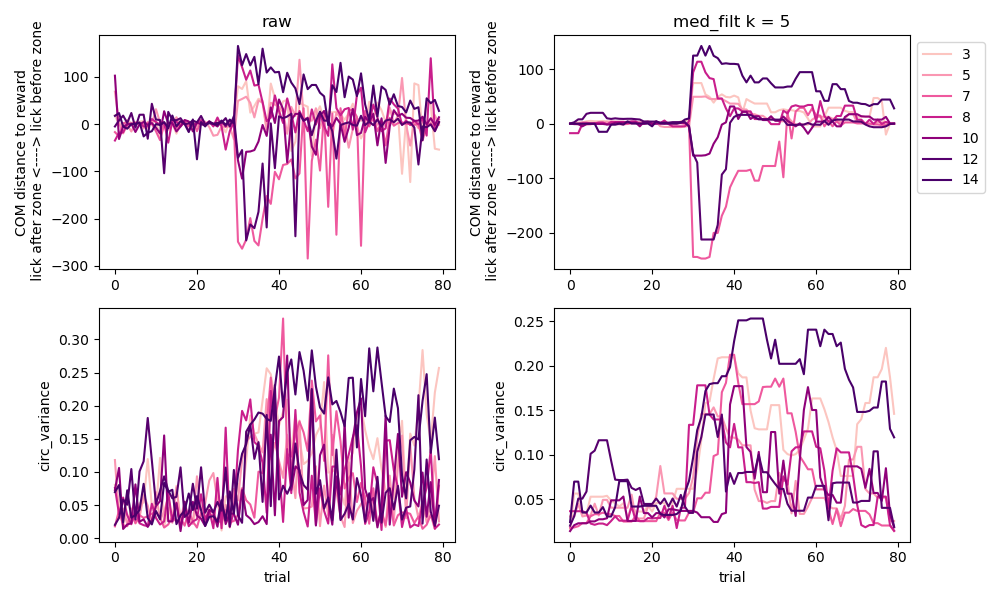

In [69]:
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib widget
cycler = mpl.cycler(color = [plt.cm.RdPu((i+out.shape[0]/4) / (out.shape[0])) for i in range(out.shape[0])])

with mpl.rc_context({'axes.prop_cycle': mpl.cycler(cycler)}):
    fig, axs = plt.subplots(ncols=2, nrows = 2, figsize = (10,6))
    
    for i, day_data in enumerate(out):
        filt = medfilt(day_data[:,0], kernel_size=5)
        axs[0,0].plot(day_data[:,0], label = exp_days[i])
        axs[0,1].plot(filt, label = exp_days[i])

        filt = medfilt(day_data[:,1], kernel_size=5)
        axs[1,0].plot(day_data[:,1], label = exp_days[i])
        axs[1,1].plot(filt, label = exp_days[i])

    

    axs[0,0].set_ylabel('COM distance to reward\n lick after zone <----> lick before zone')
    axs[0,1].set_ylabel('COM distance to reward\n lick after zone <----> lick before zone')

    axs[1,0].set_ylabel('circ_variance')
    axs[1,1].set_ylabel('circ_variance')

    [ax.set_xlabel('trial') for ax in axs[1,:]]

    axs[0,0].set_title('raw')
    axs[0,1].set_title('med_filt k = 5')
    axs[0,1].legend(loc = 'upper left', bbox_to_anchor = (1,1))
    fig.tight_layout()


[(-2.0, 82.0), (-2.0, 82.0)]

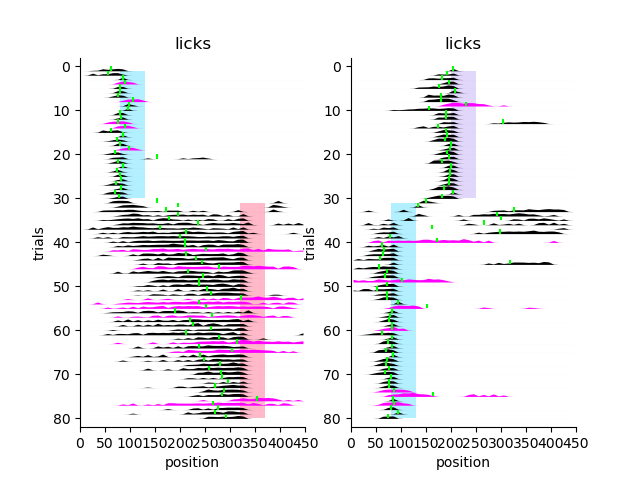

In [70]:
lick_sess = animal_sessions['GCAMP14'][14]
isreward, morph = behavior.get_trial_types(
                    lick_sess)

fig, axs = plt.subplots(ncols = 2)
_ = behavior.plot_norm_lick_raster(lick_sess,
    isreward = isreward,
    # sort_by= sorter,
    correct_sensor_error = True,
    ax = axs[0])



licks = lick_sess.trial_matrices['licks_adj'][0]


positions = np.asarray(lick_sess.trial_matrices['licks_adj'][-1])
coms = np.average(np.broadcast_to(positions, (80, 45)), weights=licks, axis = 1).reshape((80,1))
_ = axs[0].eventplot(coms, lineoffsets=np.asarray([i for i in range(licks.shape[0], 0, -1)])-0.5, colors = 'lime')




lick_sess = animal_sessions['GCAMP14'][12]
isreward, morph = behavior.get_trial_types(
                    lick_sess)
_ = behavior.plot_norm_lick_raster(lick_sess, correct_sensor_error = True, ax = axs[1],isreward = isreward,)
licks = lick_sess.trial_matrices['licks_adj'][0]

positions = np.asarray(lick_sess.trial_matrices['licks_adj'][-1])
coms = np.average(np.broadcast_to(positions, (80, 45)), weights=licks, axis = 1).reshape((80,1))
_ = axs[1].eventplot(coms, lineoffsets=np.asarray([i for i in range(licks.shape[0], 0, -1)])-0.5, colors = 'lime')

[ax.set_ylim(top = 82, bottom = -2) for ax in axs[:]]

In [71]:
axs[0].set_title('licks: day 14')

axs[1].set_title('licks: day 8')

Text(0.5, 1.0, 'licks: day 8')

In [72]:
import gc
import sys

def get_obj_size(obj):
    marked = {id(obj)}
    obj_q = [obj]
    sz = 0

    while obj_q:
        sz += sum(map(sys.getsizeof, obj_q))

        # Lookup all the object referred to by the object in obj_q.
        # See: https://docs.python.org/3.7/library/gc.html#gc.get_referents
        all_refr = ((id(o), o) for o in gc.get_referents(*obj_q))

        # Filter object that are already marked.
        # Using dict notation will prevent repeated objects.
        new_refr = {o_id: o for o_id, o in all_refr if o_id not in marked and not isinstance(o, type)}

        # The new obj_q will be the ones that were not marked,
        # and we will update marked with their ids so we will
        # not traverse them again.
        obj_q = new_refr.values()
        marked.update(new_refr.keys())

    return sz

In [73]:
get_obj_size(animal_sessions['GCAMP14'][3])

10208163

In [74]:
all_obs = 0
for k,obj in animal_sessions['GCAMP14'][3].__dict__.items():
    print(f'{k}, {get_obj_size(obj)/1e6} MB')
    all_obs += get_obj_size(obj)
print(f"sum: {all_obs/1e6} MB")


vr_data, 10.150768 MB
trial_start_inds, 0.001888 MB
teleport_inds, 0.001888 MB
scan_info, 0.003875 MB
n_planes, 2.8e-05 MB
timeseries, 0.001424 MB
trial_matrices, 0.013664 MB
iscell, 0.000128 MB
plane_per_cell, 0.000112 MB
s2p_ops, 0.027671 MB
s2p_stats, 0.006136 MB
basedir_2P, 1.6e-05 MB
basedir_VR, 1.6e-05 MB
mouse, 5.6e-05 MB
date, 5.9e-05 MB
scene, 6.8e-05 MB
session, 2.8e-05 MB
scan_number, 2.8e-05 MB
scanner, 5.2e-05 MB
VR_only, 2.8e-05 MB
scan_file, 0.000145 MB
scanheader_file, 0.000145 MB
vr_filename, 0.000119 MB
s2p_path, 0.000138 MB
prompt_for_keys, 2.8e-05 MB
verbose, 2.8e-05 MB
basedir, 7.1e-05 MB
sum: 10.208607 MB


In [75]:
animal_sessions['GCAMP14'][3].vr_data

,time,morph,dreamland,trialnum,pos,dz,posx,lick,reward,tstart,teleport,rzone,scanning,manrewards,autoreward,cmd,speed,lick rate
0,0.000000,-1.0,-1.0,-1.0,-500.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,-1.0,0.000000,0.000000
1,0.064484,-1.0,-1.0,-1.0,-500.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,-1.0,0.000000,0.000000
2,0.128967,-1.0,-1.0,-1.0,-500.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,-1.0,0.000000,0.000000
3,0.193451,-1.0,-1.0,-1.0,-500.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,-1.0,0.000000,0.000000
4,0.257935,-1.0,-1.0,-1.0,-500.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,-1.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22572,1455.524433,0.0,0.0,79.0,440.121255,1.306087,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,20.254545,0.948966
22573,1455.588917,0.0,0.0,79.0,442.786159,1.033912,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,16.033706,0.617252
22574,1455.653401,0.0,0.0,79.0,445.489825,0.717004,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,11.119161,0.395961
22575,1455.717884,0.0,0.0,79.0,448.271018,0.367211,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.694641,0.262067


In [76]:
get_obj_size(animal_sessions['GCAMP14'][3].vr_data)/1e9

0.010151744

In [77]:
vr_dat = animal_sessions['GCAMP14'][3].vr_data
for col in vr_dat.columns:
    print(f'{col} : {vr_dat[col].dtype}: {sys.getsizeof(vr_dat[col])/1000}: {sys.getsizeof(vr_dat[col].astype("float16"))/1000}')

time : float64: 361.264: 225.802
morph : float64: 361.264: 225.802
dreamland : float64: 361.264: 225.802
trialnum : float64: 361.264: 225.802
pos : float64: 361.264: 225.802
dz : float64: 361.264: 225.802
posx : float64: 361.264: 225.802
lick : float64: 361.264: 225.802
reward : float64: 361.264: 225.802
tstart : float64: 361.264: 225.802
teleport : float64: 361.264: 225.802
rzone : float64: 361.264: 225.802
scanning : float64: 361.264: 225.802
manrewards : float64: 361.264: 225.802
autoreward : float64: 361.264: 225.802
cmd : float64: 361.264: 225.802
speed : float64: 361.264: 225.802
lick rate : float64: 361.264: 225.802


In [78]:
# df.memory_usage(deep=True)
vr_dat.memory_usage(deep=True).sum()/1e9

0.003431704

In [79]:
sys.getsizeof(animal_sessions['GCAMP14'][3].vr_data.astype(np.float16))/1000

993.42

In [80]:
import sys

get_obj_size(animal_sessions['GCAMP14'][5])/1000

8711.143

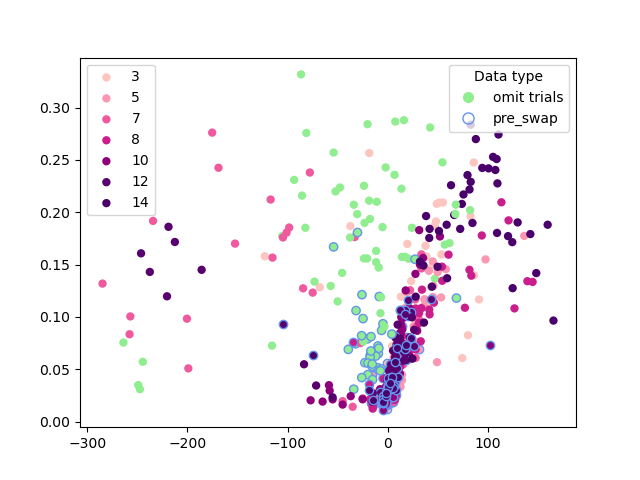

In [81]:
colors = [plt.cm.RdPu((i+out.shape[0]/4) / (out.shape[0])) for i in range(out.shape[0])]

with mpl.rc_context({'axes.prop_cycle': mpl.cycler(cycler)}):
    fig, ax = plt.subplots()
    
    for i, day_data in enumerate(out):
        isreward, morph = behavior.get_trial_types(
                    animal_sessions['GCAMP14'][exp_days[i]])
        
        omit_pre = np.logical_not(isreward)[:30]
        omit_post = np.logical_not(isreward)[30:]

        ax.scatter(day_data[:30,0][~omit_pre], day_data[:30,1][~omit_pre], edgecolors='cornflowerblue', color = colors[i])
        ax.scatter(day_data[30:,0][~omit_post], day_data[30:,1][~omit_post], edgecolors='None',color = colors[i], label = exp_days[i])

        omit_pre = np.logical_not(isreward)[:30]
        omit_post = np.logical_not(isreward)[30:]

        ax.scatter(day_data[:30,0][omit_pre], day_data[:30,1][omit_pre], edgecolors='cornflowerblue', c = ['lightgreen']*sum(omit_pre))
        ax.scatter(day_data[30:,0][omit_post], day_data[30:,1][omit_post], edgecolors='None',c = ['lightgreen']*sum(omit_post))


    

leg1 = ax.legend(loc = 'upper left')

# proxy artists for second legend
markers = [
    Line2D([0], [0], marker='o', color='lightgreen', markerfacecolor='lightgreen', 
           markeredgecolor='None', markersize=8, label='omit trials', linestyle='None'),
    Line2D([0], [0], marker='o', color='lightgreen', markerfacecolor='none', 
           markeredgecolor='cornflowerblue', markersize=8, label='pre_swap', linestyle="None"),
]


leg2 = ax.legend(handles=markers, loc='upper right', 
                bbox_to_anchor=(1, 1), title='Data type')

# must re-add leg1 — adding leg2 removes it by default
ax.add_artist(leg1, )
    
    

In [82]:
plt.close('all')

Text(0.5, 1.0, 'swap backward')

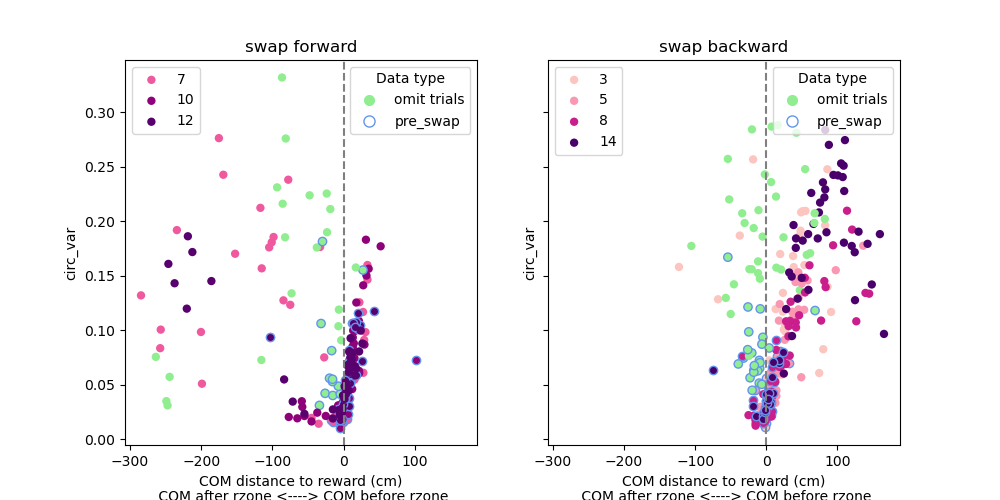

In [83]:
colors = [plt.cm.RdPu((i+out.shape[0]/4) / (out.shape[0])) for i in range(out.shape[0])]

with mpl.rc_context({'axes.prop_cycle': mpl.cycler(cycler)}):
    fig, axs = plt.subplots(ncols = 2, sharex = True, sharey = True, figsize = (10, 5))
    
    for i, day_data in enumerate(out):

        session = animal_sessions['GCAMP14'][exp_days[i]]
        isreward, morph = behavior.get_trial_types(
                    session)
        
        rzones =  behavior.get_reward_zones(session)[0]

        if rzones[0][0]>rzones[-1][0]:
            ax = axs[0]
        else:
            ax = axs[1]
        
        omit_pre = np.logical_not(isreward)[:30]
        omit_post = np.logical_not(isreward)[30:]

        ax.scatter(day_data[:30,0][~omit_pre], day_data[:30,1][~omit_pre], edgecolors='cornflowerblue', color = colors[i])
        ax.scatter(day_data[30:,0][~omit_post], day_data[30:,1][~omit_post], edgecolors='None',color = colors[i], label = exp_days[i])

        omit_pre = np.logical_not(isreward)[:30]
        omit_post = np.logical_not(isreward)[30:]

        ax.scatter(day_data[:30,0][omit_pre], day_data[:30,1][omit_pre], edgecolors='cornflowerblue', c = ['lightgreen']*sum(omit_pre))
        ax.scatter(day_data[30:,0][omit_post], day_data[30:,1][omit_post], edgecolors='None',c = ['lightgreen']*sum(omit_post))


    



# must re-add leg1 — adding leg2 removes it by default

for ax in axs[:]:


    ax.axvline(x = 0, linestyle = '--', color = 'gray')

    leg1 = ax.legend(loc = 'upper left')

    # proxy artists for second legend
    markers = [
        Line2D([0], [0], marker='o', color='lightgreen', markerfacecolor='lightgreen', 
            markeredgecolor='None', markersize=8, label='omit trials', linestyle='None'),
        Line2D([0], [0], marker='o', color='lightgreen', markerfacecolor='none', 
            markeredgecolor='cornflowerblue', markersize=8, label='pre_swap', linestyle="None"),
    ]


    leg2 = ax.legend(handles=markers, loc='upper right', 
                    bbox_to_anchor=(1, 1), title='Data type')
    ax.add_artist(leg1, )
    ax.set_xlabel('COM distance to reward (cm)\n COM after rzone <----> COM before rzone')
    ax.set_ylabel('circ_var')

axs[0].set_title('swap forward')
axs[1].set_title('swap backward')



In [84]:
from reward_relative import rewardAnalysis as ra

ra.get_omission_trials(animal_sessions['GCAMP14'][5])

{'start_inds': [184,
  748,
  1940,
  3275,
  4820,
  5603,
  5888,
  6174,
  6704,
  7224,
  8596,
  9503,
  10755,
  13402,
  14286,
  17647],
 'teleport_inds': [428,
  930,
  2082,
  3441,
  4986,
  5759,
  6060,
  6327,
  6866,
  7376,
  8817,
  9691,
  10937,
  13578,
  14446,
  17817],
 'trials': [0, 2, 7, 13, 20, 23, 24, 25, 27, 29, 34, 37, 42, 53, 57, 72]}

In [85]:
swap_distal = np.zeros((560), dtype=bool)

for i, day_data in enumerate(out):

    session = animal_sessions['GCAMP14'][exp_days[i]]
    isreward, morph = behavior.get_trial_types(
                session)
    
    rzones =  behavior.get_reward_zones(session)[0]

    if rzones[-1][0]>rzones[0][0]:
        swap_distal[i*80:(i+1)*80] = True

In [124]:
sum(rzones[:,0]==rzones[0,0])

30

In [87]:
out.reshape(-1, 2).transpose().shape

(2, 560)

In [88]:
embedding.reshape(7,80,2)[:,:30,:].reshape(-1,2)

array([[ 8.39294720e+00, -1.56980705e+00],
       [ 1.20510082e+01, -2.42293596e+00],
       [ 1.34057083e+01,  1.46711516e+00],
       [ 1.16942530e+01, -2.98315573e+00],
       [ 1.54166889e+01, -5.76610386e-01],
       [ 1.37140007e+01, -1.18116224e+00],
       [ 1.33306656e+01, -2.98255324e+00],
       [ 1.28712540e+01, -2.70025277e+00],
       [ 7.04259682e+00, -3.53627324e+00],
       [ 1.39885511e+01, -2.19317198e+00],
       [ 1.30489740e+01, -1.65040052e+00],
       [ 6.12613106e+00, -3.05852151e+00],
       [ 1.34469681e+01,  1.66070604e+00],
       [ 1.42849464e+01, -1.78836882e+00],
       [ 1.47121401e+01,  8.74870062e-01],
       [ 5.94898081e+00, -3.41762114e+00],
       [ 1.51474171e+01, -6.02140963e-01],
       [ 1.34874277e+01, -2.34930754e+00],
       [ 1.56838198e+01, -4.17441934e-01],
       [ 1.47502346e+01, -9.38381672e-01],
       [ 6.21269894e+00, -3.93848634e+00],
       [ 1.35604658e+01, -2.90117550e+00],
       [ 1.46352825e+01,  8.13026786e-01],
       [ 1.

In [92]:
len([[True]*30+[False]*50]*7)

7

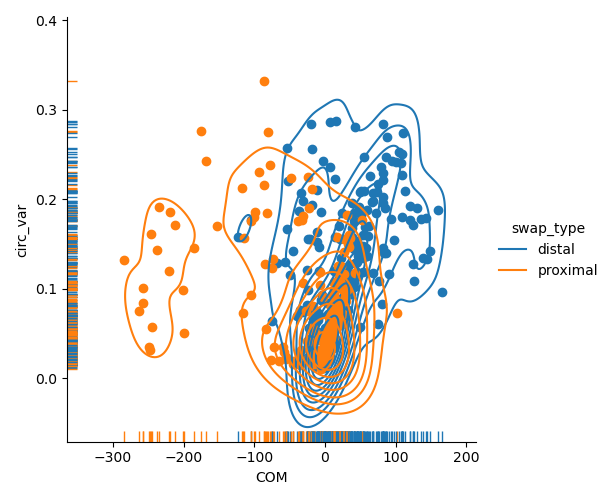

In [103]:
import seaborn as sns
import pandas as pd
# fig, ax = plt.subplots()
dat_df = pd.DataFrame(data = out.reshape(-1, 2), columns = ['COM', 'circ_var'])
dat_df['omit'] = all_omits
dat_df['swap_type'] = 'distal'
dat_df.loc[~swap_distal, 'swap_type'] = 'proximal'
one_set = [True]*30+[False]*50
slicer = [True]*30+[False]*50
for i in range(6):
    slicer += one_set
dat_df.loc[slicer]
sns.displot(dat_df, x = 'COM', y = 'circ_var', hue = 'swap_type', kind = 'kde', rug = True)
plt.scatter(dat_df.loc[dat_df.swap_type == 'distal']['COM'], dat_df.loc[dat_df.swap_type == 'distal']['circ_var'])
plt.scatter(dat_df.loc[dat_df.swap_type == 'proximal']['COM'], dat_df.loc[dat_df.swap_type == 'proximal']['circ_var'])


In [ ]:

out.reshape(-1, 2).transpose()[0,80]

68.60468609191952

In [ ]:
import scipy.stats as sts

kde = sts.gaussian_kde(out.reshape(-1, 2).transpose())

In [ ]:
kde.covariance

array([[4.19490805e+02, 6.56684301e-02],
       [6.56684301e-02, 5.64594975e-04]])

In [39]:
import umap

reducer = umap.UMAP(n_neighbors=30)

embedding = reducer.fit_transform(out.reshape(-1, 2))
embedding.shape

2026-06-22 17:10:29.162358: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-22 17:10:29.187356: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


(560, 2)

/home/sosalab/miniconda3/envs/umap_env/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/sosalab/miniconda3/envs/umap_env/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/sosalab/miniconda3/envs/umap_env/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the s

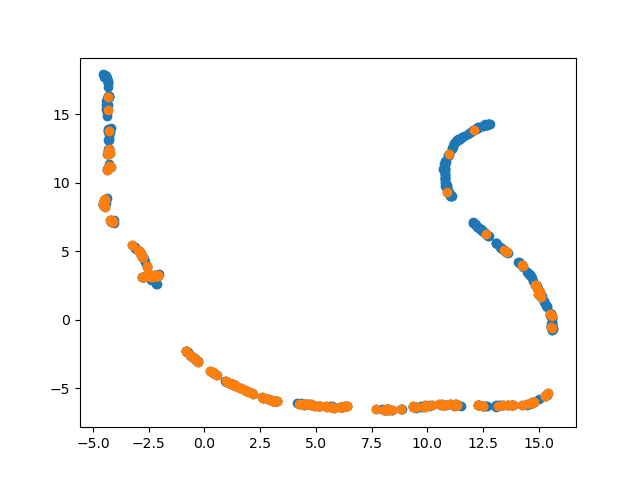

In [40]:
import umap.plot
fig, ax = plt.subplots()
ax.scatter(embedding[:,0], embedding[:,1])

pre_trials = embedding.reshape(7,80,2)[:,:30,:].reshape(-1,2)

ax.scatter(pre_trials[:,0], pre_trials[:,1])

In [41]:
all_licking = np.zeros((560, 45))
all_omits = np.zeros((560), dtype = bool)
i = 0
for key, session in animal_sessions['GCAMP14'].items():
    
    licks = pf.correct_licks(session)
    licks_smoothed = pf.smooth_trial_matrix(licks)
    all_licking[i*80:(i+1)*80,:] = licks_smoothed

    isreward, morph = behavior.get_trial_types(
                    animal_sessions['GCAMP14'][exp_days[i]])
        
    all_omits[i*80:(i+1)*80] = np.logical_not(isreward.astype(int))

    i+=1


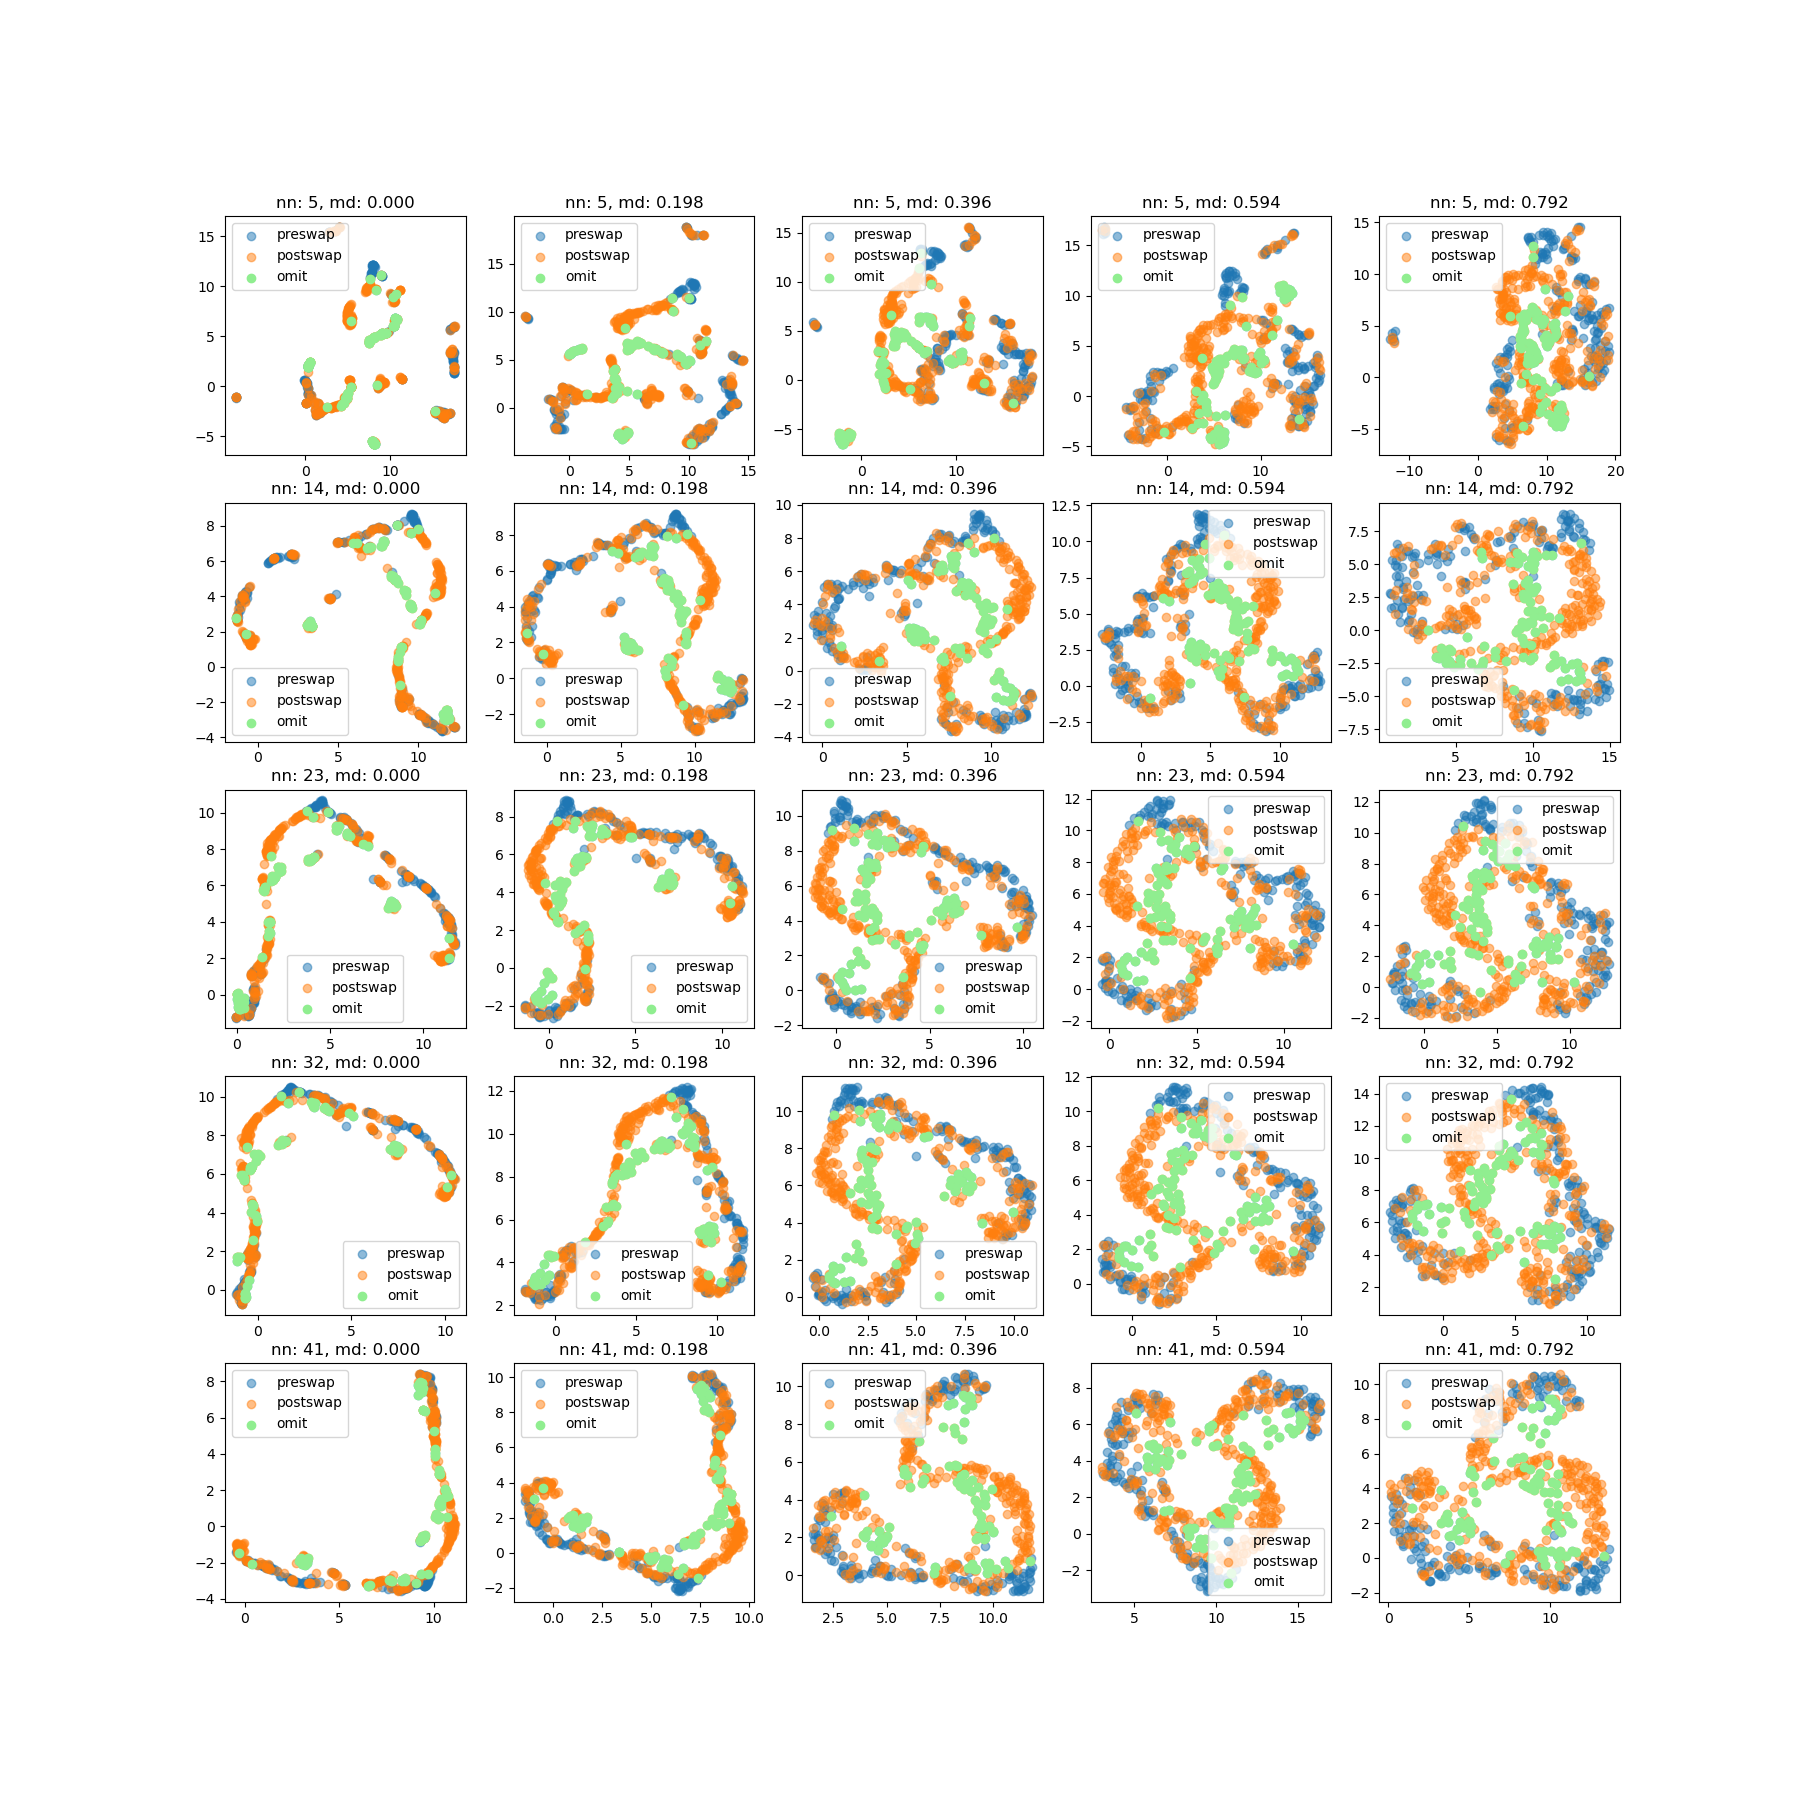

In [350]:



fig, axs = plt.subplots(ncols = 5, nrows = 5, figsize = (18,18))

for i, n_neighbor in enumerate(np.arange(5, 50, 9)):
    for j, min_dist in enumerate(np.arange(0, 0.99, 0.99/5)):
        
        reducer = umap.UMAP(n_neighbors=int(n_neighbor), min_dist=min_dist)

        embedding = reducer.fit_transform(all_licking)

        pre_trials = embedding.reshape(7,80,2)[:,:30,:].reshape(-1,2)
        post = embedding.reshape(7,80,2)[:,30:,:].reshape(-1,2)

        axs[i,j].scatter(pre_trials[:,0], pre_trials[:,1], alpha = 0.5, label = 'preswap')
        axs[i,j].scatter(post[:,0], post[:,1], alpha = 0.5, label = 'postswap')

        axs[i,j].scatter(embedding[all_omits, 0], embedding[all_omits, 1], color = 'lightgreen', label = 'omit')
        axs[i,j].legend()
        axs[i,j].set_title(f'nn: {int(n_neighbor)}, md: {min_dist:.3f}')

In [60]:
plt.close(fig)

In [125]:
import importlib
pf = importlib.reload(pf)
ti = pf.TrialInfo(animal_sessions['GCAMP14'])

In [128]:
ti.lookup_df.loc[(ti.lookup_df.idx>155) & (ti.lookup_df.idx<170)]

,idx,day,trial,reward_zone_start,reward_zone_end,trial_type,swap_type,omit
76,156,5,76,320,370,post_swap,swap_distal,False
77,157,5,77,320,370,post_swap,swap_distal,False
78,158,5,78,320,370,post_swap,swap_distal,False
79,159,5,79,320,370,post_swap,swap_distal,False
0,160,7,0,320,370,pre_swap,swap_proximal,False
1,161,7,1,320,370,pre_swap,swap_proximal,True
2,162,7,2,320,370,pre_swap,swap_proximal,False
3,163,7,3,320,370,pre_swap,swap_proximal,False
4,164,7,4,320,370,pre_swap,swap_proximal,False
5,165,7,5,320,370,pre_swap,swap_proximal,False


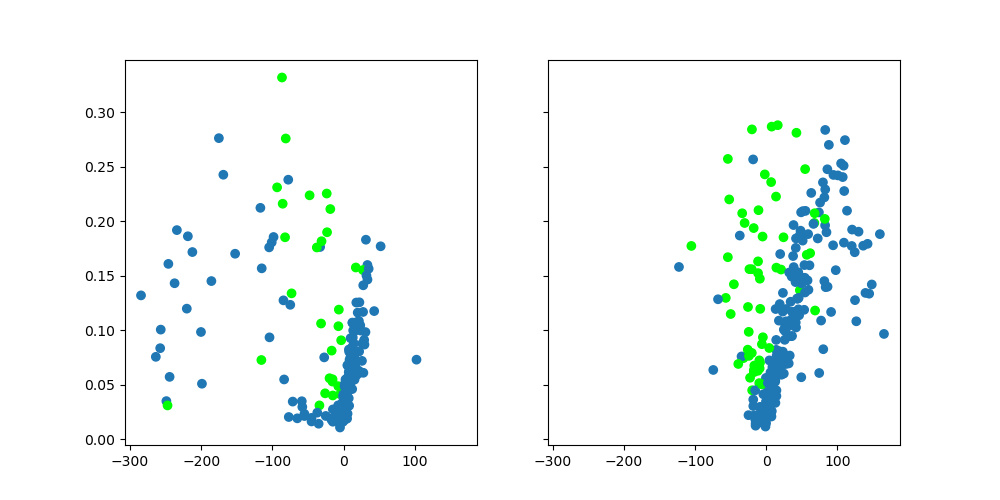

In [246]:
import protter_plot_functions as ppf

ppf = importlib.reload(ppf)

all_trials_lick_metrics = out.reshape(-1, 2)

fig, axs = plt.subplots(ncols = 2, sharex = True, sharey = True, figsize = (10, 5))



prox_meta = ti.lookup_df.loc[ti.lookup_df.swap_type == 'swap_proximal']
prox_data = all_trials_lick_metrics[ti.lookup_df.swap_type == 'swap_proximal']

distal_meta = ti.lookup_df.loc[ti.lookup_df.swap_type == 'swap_distal']
distal_data = all_trials_lick_metrics[ti.lookup_df.swap_type == 'swap_distal']

prox_scatter = axs[0].scatter(prox_data[:,0], prox_data[:,1])
prox_view = ppf.ScatterView(prox_data, prox_meta, prox_scatter)

distal_scatter = axs[1].scatter(distal_data[:,0], distal_data[:,1])
distal_view = ppf.ScatterView(distal_data, distal_meta, distal_scatter)

prox_view.set_trial_ids_to_facecolor(prox_meta.loc[prox_meta['omit']==True]['idx'].values, color='lime')
distal_view.set_trial_ids_to_facecolor(distal_meta.loc[distal_meta['omit']==True]['idx'].values, color='lime')

In [247]:
tm = animal_sessions['GCAMP14'][3].trial_matrices['licks']
bin_centers = tm[3]

In [317]:
np.unique(ti.lookup_df['day'])

array([ 3,  5,  7,  8, 10, 12, 14])

In [314]:
pd.api.types.is_integer_dtype(ti.lookup_df['day'].values)

True

In [355]:
# reducer = umap.UMAP(n_neighbors=5, min_dist=0.4)
reducer = umap.UMAP(n_neighbors=30, min_dist=0.4)

embedding = reducer.fit_transform(all_licking)

In [356]:
import hdbscan
labels = hdbscan.HDBSCAN(
    min_samples=1,
    min_cluster_size=5,
).fit_predict(embedding)

In [357]:
ti.lookup_df['hbd_labels'] = labels

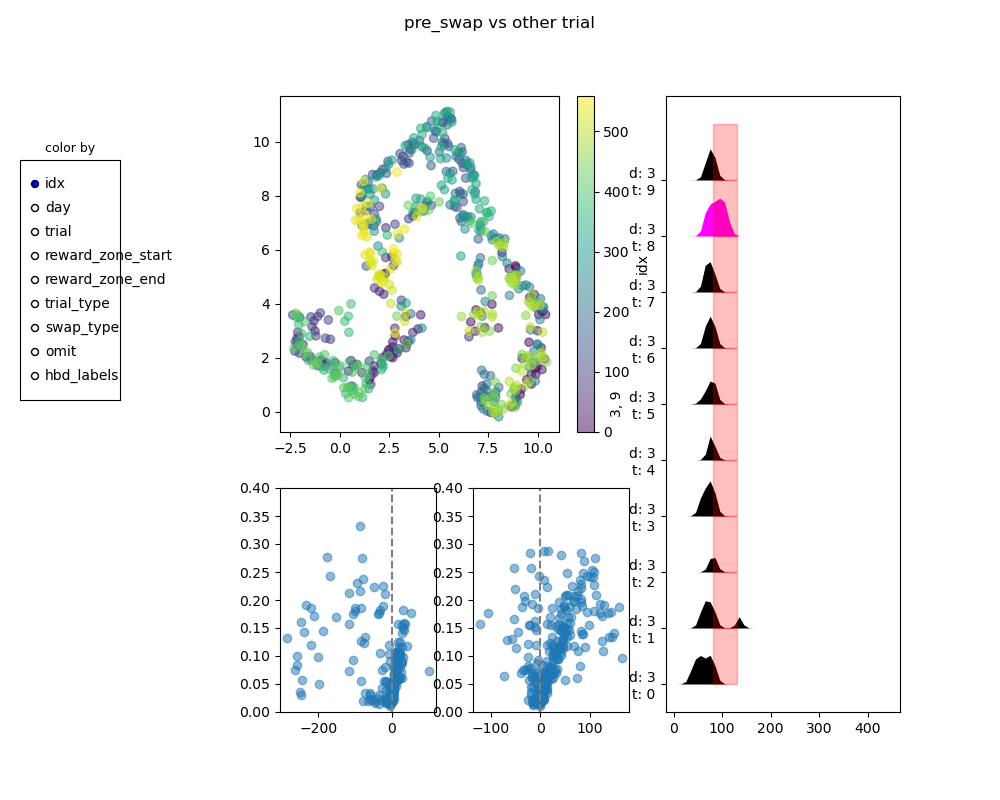

In [387]:

ppf = importlib.reload(ppf)
from protter_plot_functions import add_hover, add_color_selector#, #add_selectors
from claude_test_space import add_selectors
from protter_plot_functions import TrialPlotLinker
linker = TrialPlotLinker(ti.lookup_df)

fig = plt.figure(figsize = (10,8))
fig.suptitle('pre_swap vs other trial')
axes_dict = fig.subplot_mosaic([['lick_umap', 'lick_umap', 'lick_raster'],
                                    ['lick_distal', 'lick_proximal', 'lick_raster'],
                                    ],
                                height_ratios = [3.0,2.0],
                                width_ratios = [2.0,2.0,3])
ax, ax2, ax3 = axes_dict['lick_umap'], axes_dict['lick_distal'], axes_dict['lick_proximal']

scatter_1 = ax.scatter(embedding[:,0], embedding[:,1], alpha = 0.5, label = 'preswap')

ax.legend()
add_hover(scatter_1, ti.lookup_df)
keeper = add_color_selector(scatter_1, ti.lookup_df)
sel = add_selectors(scatter_1, linker, ti.lookup_df)


umap_view = ppf.ScatterView(data = embedding, meta = ti.lookup_df, plt_obj = scatter_1)

prox_meta = ti.lookup_df.loc[ti.lookup_df.swap_type == 'swap_proximal']
prox_data = all_trials_lick_metrics[ti.lookup_df.swap_type == 'swap_proximal']

distal_meta = ti.lookup_df.loc[ti.lookup_df.swap_type == 'swap_distal']
distal_data = all_trials_lick_metrics[ti.lookup_df.swap_type == 'swap_distal']

prox_scatter = ax2.scatter(prox_data[:,0], prox_data[:,1], alpha = 0.5)
prox_view = ppf.ScatterView(prox_data, prox_meta, prox_scatter)

distal_scatter = ax3.scatter(distal_data[:,0], distal_data[:,1], alpha = 0.5)
distal_view = ppf.ScatterView(distal_data, distal_meta, distal_scatter)

sel2 = add_selectors(prox_scatter, linker, prox_meta)
sel3 = add_selectors(distal_scatter, linker, distal_meta)

for ax in [ax2, ax3]:
    ax.set_ylim((0, 0.4))
    ax.axvline(x = 0, linestyle = '--', color = 'gray')





lick_ax = axes_dict['lick_raster']
raster_view = ppf.LickRasterView(all_licking, bin_centers, ti.lookup_df, lick_ax)
linker.add_views([prox_view, distal_view, umap_view, raster_view])


In [371]:
set([1,2,3]) | set([3,15,10])

{1, 2, 3, 10, 15}

In [362]:
umap_view.alpha_on_deselect

0.2

In [365]:
umap_view.alpha_on_deselect = 0.2

In [341]:
from matplotlib.colors import LinearSegmentedColormap
cm = LinearSegmentedColormap.from_list('MgK', ['black', 'magenta', 'black'])

omits = raster_view.metadata['omit'].astype(int)

0     False
1     False
2      True
3     False
4     False
      ...  
75    False
76    False
77    False
78    False
79    False
Name: hbd_labels, Length: 560, dtype: bool

In [334]:
np.where(ti.lookup_df['hbd_labels']== -1)[0]

array([  2,   7,  14,  19,  22,  26,  31,  33,  34,  43,  48,  51,  55,
        58,  59,  61,  62,  63,  66,  67,  68,  70,  71,  78,  91,  95,
        99, 114, 132, 146, 157, 170, 176, 179, 195, 228, 236, 238, 249,
       250, 254, 264, 266, 270, 302, 304, 317, 320, 332, 337, 345, 346,
       347, 350, 351, 352, 353, 356, 358, 361, 362, 367, 369, 371, 374,
       381, 383, 386, 388, 390, 410, 412, 413, 418, 434, 451, 456, 499,
       503, 514, 515, 533, 535, 542])

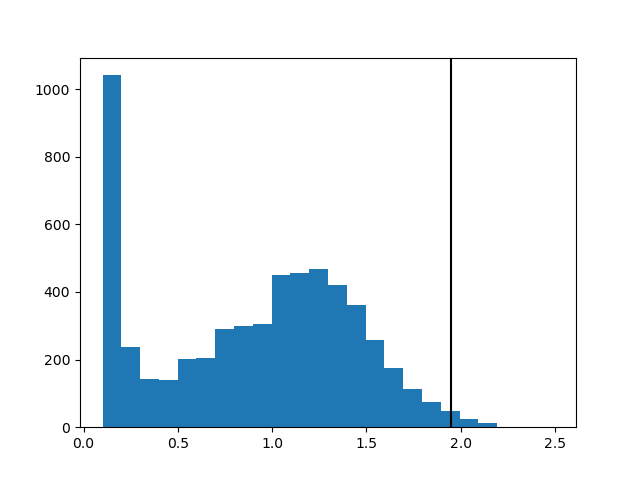

In [240]:
fig, ax = plt.subplots()
ax.hist(all_licking.ravel()[all_licking.ravel()>0.1], bins = 'auto')
pct = np.percentile(all_licking.ravel()[all_licking.ravel()>0.1], 99)
ax.axvline(pct, color = 'black')

In [129]:
ti.lookup_df

,idx,day,trial,reward_zone_start,reward_zone_end,trial_type,swap_type,omit
0,0,3,0,80,130,pre_swap,swap_distal,False
1,1,3,1,80,130,pre_swap,swap_distal,False
2,2,3,2,80,130,pre_swap,swap_distal,False
3,3,3,3,80,130,pre_swap,swap_distal,False
4,4,3,4,80,130,pre_swap,swap_distal,False
...,...,...,...,...,...,...,...,...
75,555,14,75,320,370,post_swap,swap_distal,True
76,556,14,76,320,370,post_swap,swap_distal,True
77,557,14,77,320,370,post_swap,swap_distal,False
78,558,14,78,320,370,post_swap,swap_distal,False


In [131]:
ti.lookup_df.swap_type == 'swap_proximal'

0     False
1     False
2     False
3     False
4     False
      ...  
75    False
76    False
77    False
78    False
79    False
Name: swap_type, Length: 560, dtype: bool

In [134]:
all_trials_lick_metrics

(560, 2)

Text(0.5, 1.0, 'swap proximal')

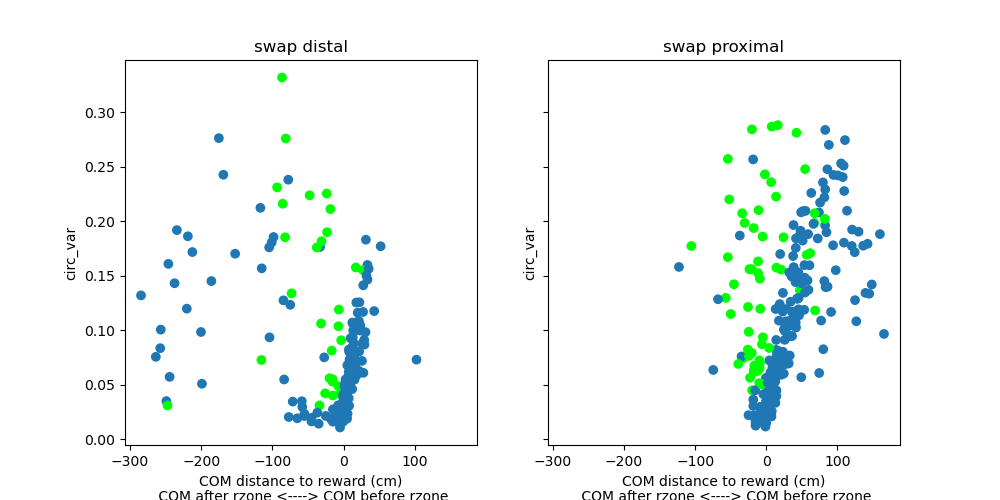

In [ ]:


    



# must re-add leg1 — adding leg2 removes it by default

for ax in axs[:]:


    ax.set_xlabel('COM distance to reward (cm)\n COM after rzone <----> COM before rzone')
    ax.set_ylabel('circ_var')

axs[0].set_title('swap distal')
axs[1].set_title('swap proximal')

In [151]:
prox_view.ids_to_positions(prox_meta.loc[prox_meta['omit']==True]['idx'].values)

array([  1,  10,  11,  18,  34,  41,  81,  85,  90,  91,  92,  95,  99,
       111, 122, 128, 136, 139, 140, 146, 149, 168, 199, 208, 214, 219,
       233, 234, 236])

In [169]:
from matplotlib.colors import to_rgba

In [170]:
scatter_colors = np.repeat(prox_scatter.get_facecolors(), len(prox_data), axis = 0)

lime = to_rgba('lime')
scatter_colors[80:100] = lime

In [171]:
prox_scatter.set_facecolors(scatter_colors)

In [164]:
np.repeat(prox_scatter.get_facecolors(), len(prox_data), axis = 0)

array([[0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667,

In [ ]:
ti.lookup_df.reward_zone_start.unique()

array([ 80, 200, 320])

15

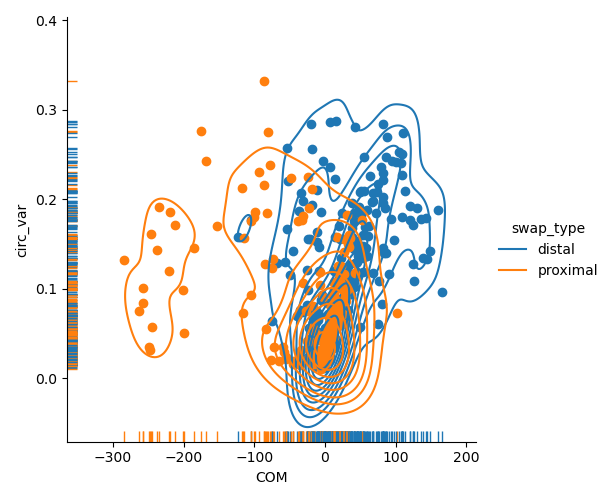

In [109]:
import seaborn as sns
import pandas as pd
# fig, ax = plt.subplots()
dat_df = pd.DataFrame(data = out.reshape(-1, 2), columns = ['COM', 'circ_var'])
dat_df['omit'] = all_omits
dat_df['swap_type'] = 'distal'
dat_df.loc[~swap_distal, 'swap_type'] = 'proximal'
one_set = [True]*30+[False]*50
slicer = [True]*30+[False]*50
for i in range(6):
    slicer += one_set
dat_df.loc[slicer]
sns.displot(dat_df, x = 'COM', y = 'circ_var', hue = 'swap_type', kind = 'kde', rug = True)
scatter_1 = plt.scatter(dat_df.loc[dat_df.swap_type == 'distal']['COM'], dat_df.loc[dat_df.swap_type == 'distal']['circ_var'])
scatter_2 = plt.scatter(dat_df.loc[dat_df.swap_type == 'proximal']['COM'], dat_df.loc[dat_df.swap_type == 'proximal']['circ_var'])

add_hover(scatter_1, ti.lookup_df.loc[dat_df.swap_type == 'distal'])
# add_hover(scatter_2, ti.lookup_df.loc[dat_df.swap_type == 'proximal'])